In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier

In [301]:
root_path = "/home/stefan/ioai-prep/kits/locala/parkinson"
seed = 42

# Data

In [302]:
def clean_df(df: pd.DataFrame):
    df = df.drop(["PatientID", "Diagnosis", "Ethnicity", "EducationLevel"], axis=1, errors="ignore")
    df = df.select_dtypes(exclude=['object'])

    df["CardiometabolicRiskScore"] = (
        df["Hypertension"] + df["Diabetes"] + (df["BMI"] > 30)
    )

    df["LifestyleRiskIndex"] = (
        df["Smoking"] + (df["AlcoholConsumption"] > 2) + (df["PhysicalActivity"] < 1)
    )

    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        dummy = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummy], axis=1)
        df = df.drop(col, axis=1)

    return df

In [303]:
train_df_ = pd.read_csv(f"{root_path}/train.csv")
train_df = clean_df(train_df_)
train_df_.head()

,PatientID,Age,AgeGroup,AlcoholConsumption,BMI,Bradykinesia,CholesterolHDL,CholesterolLDL,CholesterolTotal,CholesterolTriglycerides,...,SleepDisorders,SleepQuality,Smoking,SpeechProblems,Stroke,SystolicBP,TraumaticBrainInjury,Tremor,UPDRS,Diagnosis
0,d4e0fb07-37c6-4c7d-a9d5-bfadc41b8164,56,1,14.401750,38.165782,False,98.305359,185.601755,214.446455,177.613258,...,False,8.839484,0,True,0,173,0,False,114.941744,0
1,97cb29cd-aa0c-4802-80ee-4fb82c0d5059,84,3,15.545237,33.877785,False,29.089431,130.446298,168.545178,237.987107,...,False,6.183109,0,False,0,111,0,True,191.992824,1
2,d9584f0e-f6fb-4821-8737-679a25f4c5cd,53,1,5.942235,30.111818,False,40.764986,186.558645,291.316103,342.071323,...,False,8.590509,0,False,0,161,0,False,121.425375,0
3,d3cb6b85-7286-4b09-9f6f-349ad8e34bd1,88,3,7.315375,19.931085,False,38.752199,191.811289,174.858648,375.127417,...,False,6.359914,0,False,0,122,1,False,30.952378,0
4,d6b091f4-099a-4f85-8417-2cb7110e4f93,77,3,6.037814,32.591481,True,32.477083,118.043431,231.507811,385.517466,...,False,4.679000,0,False,0,113,0,True,63.069273,1


In [304]:
X_train, X_test, y_train, y_test = train_test_split(train_df, train_df_["Diagnosis"], test_size=0.2, random_state=seed)

## EDA

In [305]:
train_df_.isna().sum().sum()

0

In [306]:
train_df_.describe()

,Age,AgeGroup,AlcoholConsumption,BMI,CholesterolHDL,CholesterolLDL,CholesterolTotal,CholesterolTriglycerides,Depression,Diabetes,...,MeanBP,MoCA,PhysicalActivity,SleepQuality,Smoking,Stroke,SystolicBP,TraumaticBrainInjury,UPDRS,Diagnosis
count,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,...,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000,1684.000000
mean,69.684679,1.941211,10.042942,27.173487,59.925097,125.829205,226.835389,223.405935,0.199525,0.146675,...,104.506730,14.952824,4.991151,7.014022,0.298100,0.049881,133.497625,0.105107,101.314153,0.619359
std,11.574388,0.900643,5.675070,7.239006,23.451561,43.500870,43.756976,101.842448,0.399762,0.353886,...,14.456452,8.606518,2.911877,1.761827,0.457559,0.217764,26.324171,0.306782,56.705259,0.485689
min,50.000000,0.000000,0.002228,15.008333,20.027981,50.130454,150.062698,50.113604,0.000000,0.000000,...,70.666667,0.021191,0.004157,4.000497,0.000000,0.000000,90.000000,0.000000,0.060213,0.000000
25%,60.000000,1.000000,5.168089,20.767862,39.856161,88.712803,189.282934,132.556941,0.000000,0.000000,...,94.000000,7.410746,2.408328,5.502953,0.000000,0.000000,110.000000,0.000000,53.475813,0.000000
50%,70.000000,2.000000,10.060746,27.137617,59.266910,126.175395,228.478394,224.881433,0.000000,0.000000,...,104.666667,14.693255,4.986861,6.935809,0.000000,0.000000,133.000000,0.000000,102.583021,1.000000
75%,80.000000,3.000000,14.772122,33.420471,80.027387,163.277013,264.640427,311.760474,0.000000,0.000000,...,115.000000,22.437446,7.496692,8.577740,1.000000,0.000000,156.000000,0.000000,149.543421,1.000000
max,89.000000,3.000000,19.979467,39.999887,99.982265,199.985981,299.963074,399.936599,1.000000,1.000000,...,137.333333,29.970107,9.995255,9.999821,1.000000,1.000000,179.000000,1.000000,198.894800,1.000000


In [307]:
train_df.select_dtypes(exclude='object').corrwith(train_df_["Diagnosis"]).sort_values(ascending=False)

UPDRS                       0.401912
Tremor                      0.275189
Rigidity                    0.182346
Bradykinesia                0.174292
PosturalInstability         0.147668
Depression                  0.076186
Age                         0.069958
AgeGroup                    0.065630
DyslipidemiaIndex           0.050609
CardiometabolicRiskScore    0.048964
AlcoholConsumption          0.046752
BMI                         0.044721
Diabetes                    0.038090
Stroke                      0.033560
CholesterolTriglycerides    0.033305
LifestyleRiskIndex          0.031807
TraumaticBrainInjury        0.029404
FamilyHistoryParkinsons     0.027719
Gender                      0.026879
CholesterolLDL              0.024628
Constipation                0.024293
Smoking                     0.013588
SleepDisorders              0.002345
PhysicalActivity           -0.002331
SystolicBP                 -0.004416
Hypertension               -0.007650
SpeechProblems             -0.008356
D

In [308]:
train_df_.select_dtypes(include=['object']).head(2)

,PatientID,DoctorInCharge,EyeColor
0,d4e0fb07-37c6-4c7d-a9d5-bfadc41b8164,Dr. Marco Rossi,Brown
1,97cb29cd-aa0c-4802-80ee-4fb82c0d5059,Dr. Ana Martínez,Green


<Axes: xlabel='DoctorInCharge', ylabel='Count'>

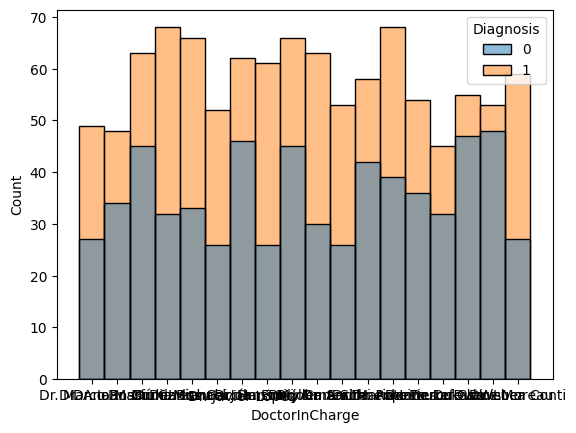

In [309]:
sns.histplot(x="DoctorInCharge", hue="Diagnosis", data=train_df_)

# Model

In [314]:
def evaluate(model):
    cv = cross_val_score(
        model, X_train, y_train, scoring="roc_auc", cv=3, n_jobs=-1
    )
    cv = cv.mean() - cv.std()

    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, preds)
    return score, cv

In [315]:
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=seed)
evaluate(rf)

(0.9594525547445254, 0.9313688652336534)

In [316]:
cb = CatBoostClassifier(eval_metric='AUC', random_state=seed, verbose=0)

evaluate(cb)

(0.977956204379562, 0.95635149186486)

In [317]:
clf = cb
clf.fit(train_df, train_df_["Diagnosis"], verbose=0)

# Submission

In [318]:
test_df_ = pd.read_csv(f"{root_path}/test.csv")
test_df = clean_df(test_df_)

In [319]:
subtask1 = test_df["CardiometabolicRiskScore"]
subtask2 = test_df["LifestyleRiskIndex"]
subtask3 = clf.predict_proba(test_df)[:, 1]

In [320]:
def build_df(sid, answers):
    return pd.DataFrame({"PatientID": test_df_["PatientID"], "subtaskID": sid, "Answer": answers})

subtasks = [
    ("Task1", subtask1),
    ("Task2", subtask2),
    ("Task3", subtask3)
]

submission_df = pd.concat([build_df(sid, ans) for sid, ans in subtasks])

In [321]:
submission_df.head()

,PatientID,subtaskID,Answer
0,a00fa494-651e-4674-8fb8-aa006b14cbf7,Task1,0.0
1,f31cda69-4e3f-4265-928c-3fe9b83f0896,Task1,1.0
2,e4d181d2-803a-42f5-8065-239dd591fb9d,Task1,0.0
3,c585efb2-37e3-4620-aeda-a2299191d3a9,Task1,2.0
4,74fbfa2b-901e-4028-b325-9aaaa07cbf4d,Task1,0.0


In [322]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)